In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import talib as ta

In [4]:
def load_data(path):
    return pd.read_csv(path, index_col="datetime", parse_dates=True)

dbtc = load_data(path='../data/binance_BTC_USDT_2019_2025_1h.csv')

In [5]:
dbtc.head(2)

,open,high,low,close,volume
datetime,,,,,
2019-01-01 00:00:00,3701.23,3713.00,3689.88,3700.31,686.367420
2019-01-01 01:00:00,3700.20,3702.73,3684.22,3689.69,613.539115


In [6]:
dbtc.describe()

,open,high,low,close,volume
count,61308.000000,61308.000000,61308.000000,61308.000000,61308.000000
mean,41496.869547,41661.558821,41324.377872,41498.236098,2891.695764
std,32265.980420,32363.366513,32165.213527,32266.160947,4197.414420
min,3366.630000,3386.970000,3349.920000,3366.410000,0.000000
25%,11783.300000,11836.975000,11722.597500,11783.517500,839.521962
50%,32135.895000,32381.895000,31830.970000,32143.155000,1552.683101
75%,61049.677500,61285.485000,60802.622500,61049.977500,3089.576166
max,126011.180000,126199.630000,125252.740000,126011.180000,137207.188600


In [7]:
def plot_price(data):
    plt.plot(data)
    plt.title("Biểu đồ giá Close") 
    plt.xlabel("Thời gian")   
    plt.ylabel("Giá")         
    plt.grid(True)        
    plt.show() 

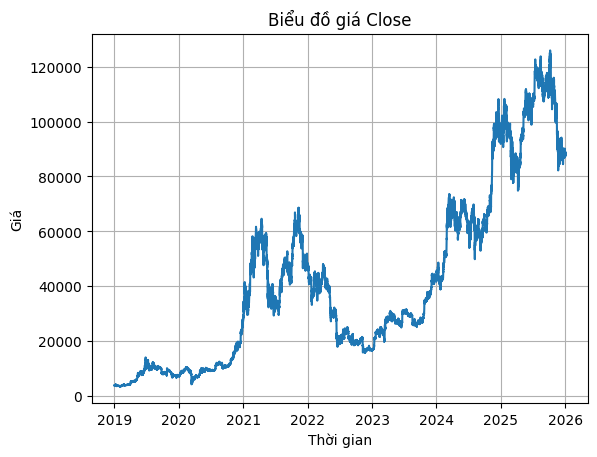

In [8]:
plot_price(dbtc.loc[:, "close"])

In [9]:
def pre_process(df):
    data = df.copy()
    EPSILON = 1e-8
    
    delta = data.index.to_series().diff()
    delta_time = delta.dt.total_seconds() / 3600
    delta_time = delta_time.fillna(1).astype(int)
    data['log_time_gap'] = np.log(delta_time)

    # 1. Temporal Features
    hours = data.index.hour
    day_of_week = data.index.dayofweek
    data['hour_sin'] = np.sin(2 * np.pi * hours / 24)
    data['hour_cos'] = np.cos(2 * np.pi * hours / 24)
    data['dow_sin'] = np.sin(2 * np.pi * day_of_week / 7)
    data['dow_cos'] = np.cos(2 * np.pi * day_of_week / 7)

    # 1. Price structure
    high_low_range = data['high'] - data['low'] + EPSILON
    data['body_ratio'] = (data['close'] - data['open']) / high_low_range

    # 2. Multi-horizon Momentum
    horizons = [1, 4, 12, 24, 168]
    for h in horizons:
        data[f'log_ret_{h}'] = np.log(data['close'] / data['close'].shift(h))

    # 3. Volatility & Risk Representation
    data['volatility_4'] = data['log_ret_1'].rolling(window=4).std()
    
    volatility_horizons = [24, 168]
    for h in volatility_horizons:
        volatility_h = data['log_ret_1'].rolling(window=h).std()
        data[f'volatility_{h}_ratio'] = data['volatility_4'] / (volatility_h + EPSILON)

    # Normalized Spread
    data['spread_hl_norm'] = np.log(data['high'] / (data['low'] + EPSILON)) / (data['volatility_4'] + EPSILON)

    # 4. Microstructure & Volume Dynamics
    typical_price = ta.TYPPRICE(data['high'], data['low'], data['close'])
    tp_vol = typical_price * data['volume']
    rolling_tp_vol = ta.SUM(tp_vol, timeperiod=24)
    rolling_vol = ta.SUM(data['volume'], timeperiod=24)
    vwap_24 = rolling_tp_vol / (rolling_vol + EPSILON)
    data['dist_vwap_24'] = (data['close'] - vwap_24) / (vwap_24 + EPSILON)
    
    # Indicator
    # RSI (Relative Strength Index) - Momentum & Overbought/Oversold
    data['rsi_14'] = ta.RSI(data['close'], timeperiod=14) / 100.0
    data['rsi_24'] = ta.RSI(data['close'], timeperiod=24) / 100.0
    #MACD (Moving Average Convergence Divergence) - Trend & Momentum
    macd, macdsignal, macdhist = ta.MACD(data['close'], fastperiod=12, slowperiod=26, signalperiod=9)
    data['macd_norm'] = macd / (data['close'] + EPSILON)
    data['macd_signal_norm'] = macdsignal / (data['close'] + EPSILON)
    data['macd_hist_norm'] = macdhist / (data['close'] + EPSILON)
    # Bollinger Bands %B (Volatility & Price Position)
    upper, middle, lower = ta.BBANDS(data['close'], timeperiod=20, nbdevup=2, nbdevdn=2, matype=0)
    data['bb_percent_b'] = (data['close'] - lower) / (upper - lower + EPSILON)
    # 4. ADX (Average Directional Index) - Trend Strength
    data['adx_14'] = ta.ADX(data['high'], data['low'], data['close'], timeperiod=14) / 100.0

    data = data.loc[(data.index >= '2020-01-01') & (data.index < '2026-01-01')]
    data = data.dropna()
    return data

In [10]:
pdbtc = pre_process(dbtc)
include = pdbtc.columns.to_list()
exclude = ["open", "high", "low", "close", "volume"]
include = [x if x not in exclude else '' for x in include]
k = []
for x in include:
    if x != '':
        k.append(x)
k
des = pdbtc.loc[:, k].describe()
des.to_csv('btc_statistics.csv')
des

,log_time_gap,hour_sin,hour_cos,dow_sin,dow_cos,body_ratio,log_ret_1,log_ret_4,log_ret_12,log_ret_24,...,volatility_168_ratio,spread_hl_norm,dist_vwap_24,rsi_14,rsi_24,macd_norm,macd_signal_norm,macd_hist_norm,bb_percent_b,adx_14
count,52576.000000,52576.000000,5.257600e+04,52576.000000,52576.000000,52576.000000,52576.000000,52576.000000,52576.000000,52576.000000,...,52576.000000,5.257600e+04,52576.000000,52576.000000,52576.000000,52576.000000,52576.000000,5.257600e+04,52576.000000,52576.000000
mean,0.000303,-0.000200,-3.209914e-05,0.000468,-0.000137,0.012264,0.000048,0.000190,0.000571,0.001143,...,0.831375,2.178101e+00,0.001022,0.508936,0.508454,0.000185,0.000185,1.512983e-07,0.514501,0.274922
std,0.019117,0.707103,7.071243e-01,0.707242,0.706985,0.495479,0.006715,0.013117,0.022304,0.032082,...,0.589917,1.756089e+00,0.015750,0.121246,0.096432,0.007483,0.007057,2.203125e-03,0.334961,0.118787
min,0.000000,-1.000000,-1.000000e+00,-0.974928,-0.900969,-1.000000,-0.201033,-0.342863,-0.372332,-0.624510,...,0.016764,-5.104019e-10,-0.297458,0.055606,0.091976,-0.167182,-0.129242,-3.794010e-02,-0.563136,0.065581
25%,0.000000,-0.707107,-7.071068e-01,-0.781831,-0.900969,-0.406154,-0.002317,-0.004484,-0.008354,-0.012590,...,0.434882,1.275286e+00,-0.006180,0.431530,0.447133,-0.002765,-0.002677,-9.906407e-04,0.264277,0.185712
50%,0.000000,0.000000,-1.836970e-16,0.000000,-0.222521,0.015400,0.000065,0.000187,0.000452,0.001004,...,0.681389,1.830296e+00,0.000727,0.508407,0.507201,0.000284,0.000285,-1.579709e-05,0.526691,0.250738
75%,0.000000,0.707107,7.071068e-01,0.781831,0.623490,0.431363,0.002509,0.005049,0.009779,0.015341,...,1.050246,2.580587e+00,0.008024,0.585284,0.568457,0.003556,0.003405,9.674262e-04,0.764981,0.343435
max,1.791759,1.000000,1.000000e+00,0.974928,1.000000,1.000000,0.160280,0.182272,0.305762,0.283191,...,6.452215,1.164030e+02,0.107595,0.958543,0.900683,0.039572,0.037399,2.545125e-02,1.575102,0.827642
